已移除 'ID' 欄位。

[A] 目標變數 'default.payment.next.month' 分佈檢查：
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

比例 (Normalize):
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


/var/folders/47/ng5hpgv939g_2t_qlqyl54zh0000gn/T/ipykernel_79728/2023470758.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, palette='pastel')


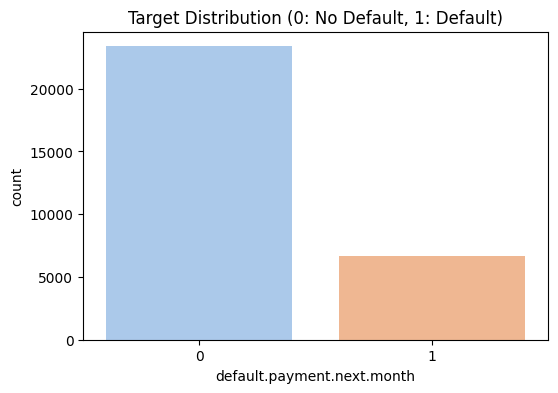


[B] 缺失值檢查：
資料集中沒有缺失值。

[C] 探索性分析圖表 (EDA)：


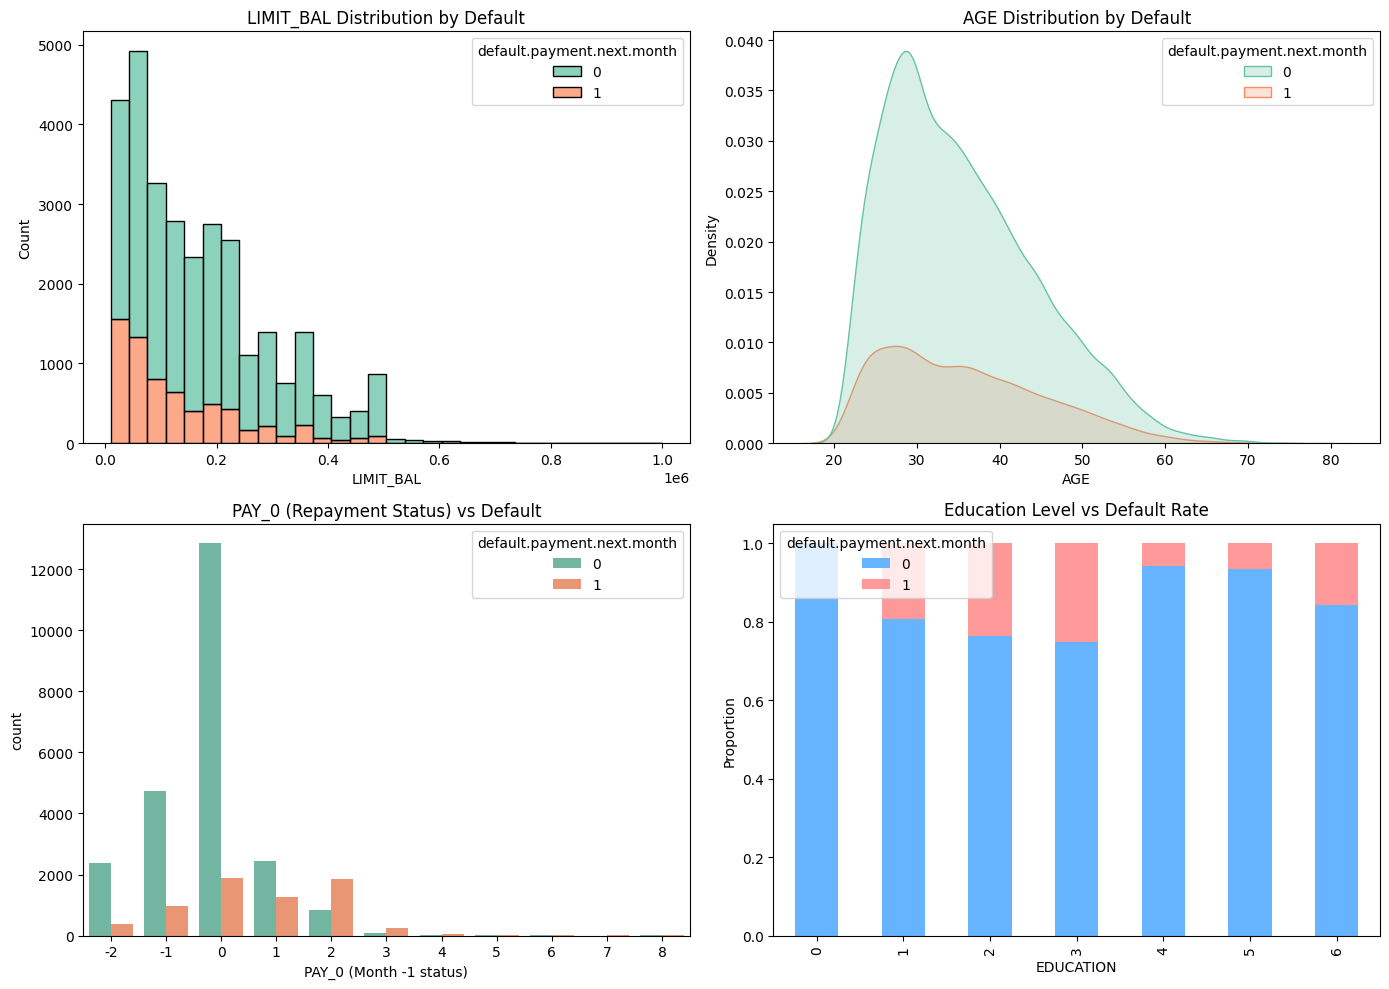

In [9]:
# Part 1: 資料前處理與探索性分析 (Data Preprocessing & EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 正確讀取資料 (設定 header=1)
filename = 'default_of_credit_card_clients.csv'
df = pd.read_csv(filename, header=1)

# 2. 欄位更名 (符合作業要求的變數名稱)
# 將 'default payment next month' 改為 'default.payment.next.month'
df.rename(columns={'default payment next month': 'default.payment.next.month'}, inplace=True)
target = 'default.payment.next.month'

# 3. 初步清理：移除 ID 欄位 (對預測無用)
if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)
    print("已移除 'ID' 欄位。")

# 4. 轉換資料型態 (確保都是數值)
# 有時候讀取會因為表頭雜訊把數字變成字串，這裡強制轉回數值
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# A. 目標變數分析 (Target Variable Analysis)
print(f"\n[A] 目標變數 '{target}' 分佈檢查：")
print(df[target].value_counts())
print("\n比例 (Normalize):")
print(df[target].value_counts(normalize=True))

# 繪製圓餅圖或長條圖檢查不平衡狀況
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df, palette='pastel')
plt.title('Target Distribution (0: No Default, 1: Default)')
plt.show()

# B. 缺失值處理 (Missing Values)
print("\n[B] 缺失值檢查：")
missing_sum = df.isnull().sum()
missing_cols = missing_sum[missing_sum > 0]

if len(missing_cols) > 0:
    print("發現缺失值，正在處理...")
    print(missing_cols)
    # 作業策略：若缺失值不多，可選擇刪除或補值。
    # 這裡採用簡單策略：若該列有缺失值則刪除 (Dropna)，也可改用 df.fillna(0)
    df.dropna(inplace=True)
    print(f"處理後剩餘筆數: {len(df)}")
else:
    print("資料集中沒有缺失值。")

# C. 探索性分析 (EDA) - 重要特徵觀察
print("\n[C] 探索性分析圖表 (EDA)：")

# 設定圖表畫布 (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 圖 1: 信用額度 (LIMIT_BAL) 與違約的關係 - 直方圖
sns.histplot(data=df, x='LIMIT_BAL', hue=target, multiple="stack", bins=30, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('LIMIT_BAL Distribution by Default')

# 圖 2: 年齡 (AGE) 與違約的關係 - KDE圖
sns.kdeplot(data=df, x='AGE', hue=target, fill=True, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('AGE Distribution by Default')

# 圖 3: 上期還款狀態 (PAY_0) 與違約的關係 - 非常重要的特徵！
# PAY_0 > 0 代表延遲繳款，通常違約率較高
sns.countplot(x='PAY_0', hue=target, data=df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('PAY_0 (Repayment Status) vs Default')
axes[1, 0].set_xlabel('PAY_0 (Month -1 status)')

# 圖 4: 教育程度 (EDUCATION) 與違約 - 堆疊長條圖
# 為了圖表清晰，我們做一個 Cross Tab
edu_crosstab = pd.crosstab(df['EDUCATION'], df[target], normalize='index')
edu_crosstab.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#66b3ff', '#ff9999'])
axes[1, 1].set_title('Education Level vs Default Rate')
axes[1, 1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()


訓練集筆數: 21000
測試集筆數: 9000

正在訓練 Logistic Regression...


/Users/user/Desktop/cgu/G5/crypto/hw01/py/venv3113/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


正在訓練 Decision Tree...

===== Logistic Regression 評估結果 =====
Accuracy: 0.8022
Classification Report:
               precision    recall  f1-score   support

No Default(0)       0.81      0.97      0.88      7009
   Default(1)       0.66      0.22      0.33      1991

     accuracy                           0.80      9000
    macro avg       0.74      0.59      0.61      9000
 weighted avg       0.78      0.80      0.76      9000



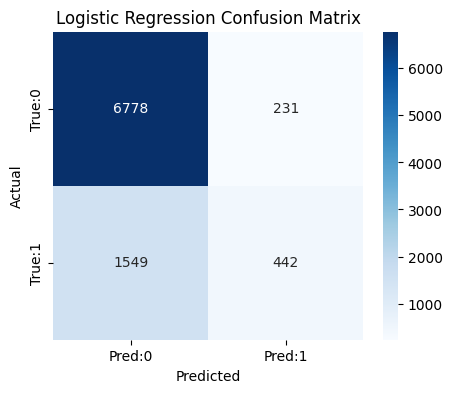


===== Decision Tree 評估結果 =====
Accuracy: 0.7232
Classification Report:
               precision    recall  f1-score   support

No Default(0)       0.83      0.81      0.82      7009
   Default(1)       0.38      0.40      0.39      1991

     accuracy                           0.72      9000
    macro avg       0.60      0.61      0.61      9000
 weighted avg       0.73      0.72      0.73      9000



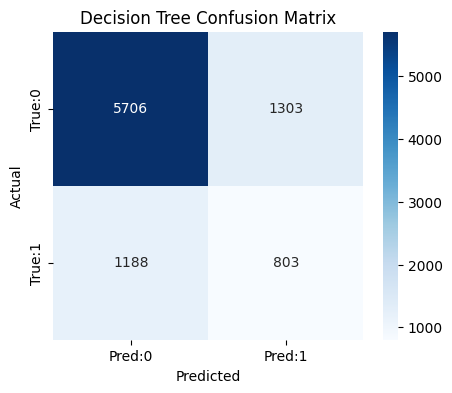

In [3]:
# Part 2: 建立基準模型 (Baseline Models)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. 準備特徵 (X) 與目標 (y)
# 目標變數剛才已經設定為 target = 'default.payment.next.month'
X = df.drop(columns=[target])
y = df[target]

# 2. 切分訓練集與測試集 (Train/Test Split)
# test_size=0.3: 30% 做測試
# stratify=y: 確保切分後的違約比例跟原始資料一樣 (非常重要！)
# random_state=42: 固定亂數種子，確保每次執行結果一樣
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"訓練集筆數: {X_train.shape[0]}")
print(f"測試集筆數: {X_test.shape[0]}")

# 模型 A: Logistic Regression (邏輯迴歸)
print("\n正在訓練 Logistic Regression...")
# max_iter=1000 避免迭代次數不足導致警告
log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train, y_train)
y_pred_log = log_clf.predict(X_test)

# 模型 B: Decision Tree (決策樹)
print("正在訓練 Decision Tree...")
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

# 評估與比較 (Evaluation)

def print_evaluation(model_name, y_true, y_pred):
    print(f"\n===== {model_name} 評估結果 =====")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Classification Report:")
    # target_names 對應 0:未違約, 1:違約
    print(classification_report(y_true, y_pred, target_names=['No Default(0)', 'Default(1)']))
    
    # 繪製混淆矩陣
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Pred:0', 'Pred:1'], 
                yticklabels=['True:0', 'True:1'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 顯示兩個模型的結果
print_evaluation("Logistic Regression", y_test, y_pred_log)
print_evaluation("Decision Tree", y_test, y_pred_tree)

正在設定參數網格與 Random Forest...
🚀 開始執行 Grid Search (這可能需要 1-3 分鐘，請稍候)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   4.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   5.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   5.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   5.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   5.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   4.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=   9.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=   9.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1,

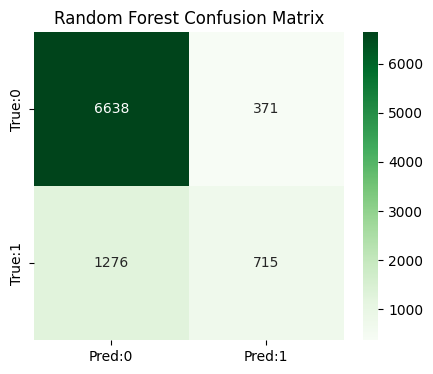

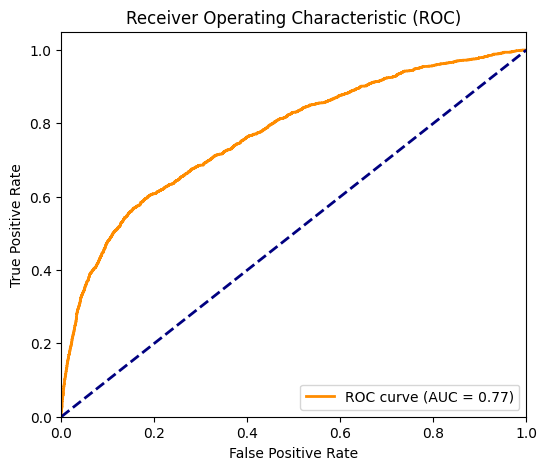

In [4]:
# Part 3: Random Forest 模型建立與調參 (Grid Search)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc

print("正在設定參數網格與 Random Forest...")

# 1. 設定參數網格 (Hyperparameter Grid)
# 依照作業說明的建議範圍設定
param_grid = {
    'n_estimators': [100, 200],       # 樹的數量
    'max_depth': [None, 10, 20],      # 樹的最大深度 (None表不限)
    'max_features': ['sqrt', 'log2'], # 分裂特徵數
    'min_samples_leaf': [1, 2]        # (選用) 葉節點最少樣本數，避免過擬合
}

# 2. 初始化模型
rf = RandomForestClassifier(random_state=42)

# 3. 設定 Grid Search
# cv=3: 做 3 折交叉驗證
# scoring='f1': 以 F1-score (針對違約類別) 作為評分標準來選最佳參數
# n_jobs=-1: 使用 M2 晶片所有核心平行運算
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, scoring='f1', verbose=2)

print("🚀 開始執行 Grid Search (這可能需要 1-3 分鐘，請稍候)...")
grid_search.fit(X_train, y_train)

# 4. 取得最佳參數與模型
best_rf = grid_search.best_estimator_
print(f"\n✅ 找到最佳參數: {grid_search.best_params_}")
print(f"最佳 Cross-Validation F1-score: {grid_search.best_score_:.4f}")

# 5. 使用最佳模型進行預測
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1] # 取得預測為 '1' (違約) 的機率，畫 ROC 用

# 6. 評估最佳模型
print("\n===== Random Forest (Best Model) 評估結果 =====")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Default(0)', 'Default(1)']))

# 繪製混淆矩陣
plt.figure(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Pred:0', 'Pred:1'], 
            yticklabels=['True:0', 'True:1'])
plt.title('Random Forest Confusion Matrix')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 隨機猜測線
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

特徵重要度排名 (Top 10):
1. PAY_0: 0.1205
2. BILL_AMT1: 0.0576
3. AGE: 0.0557
4. BILL_AMT2: 0.0526
5. LIMIT_BAL: 0.0526
6. PAY_AMT1: 0.0505
7. BILL_AMT3: 0.0505
8. BILL_AMT6: 0.0491
9. BILL_AMT5: 0.0490
10. BILL_AMT4: 0.0481


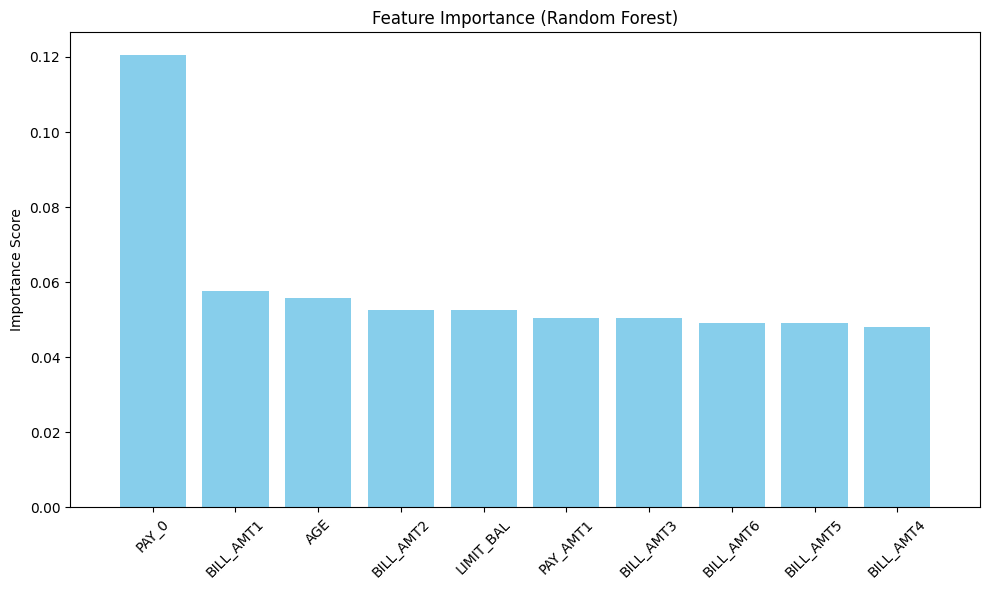


===== 獨家優化：最佳機率切點分析 =====
預設切點 (0.50) 的 F1-score: 0.4647
最佳切點 (0.2942) 的 F1-score: 0.5383

[優化後] 混淆矩陣 (Using Optimal Threshold):


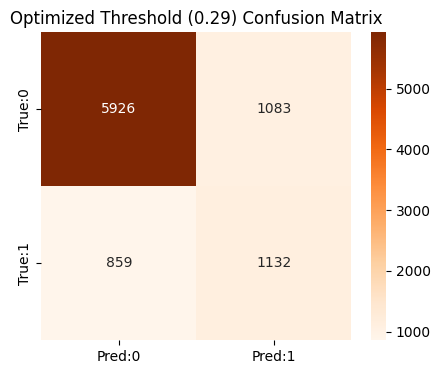

優化解讀：
調整切點後，請觀察 Recall (抓到多少違約者) 是否有提升？這對銀行風控更有價值。


In [5]:
# Part 4: 模型解釋與進階優化 (Feature Importance & Threshold Tuning)

# A. 特徵重要度 (Feature Importance) - 作業要求
# 取得特徵重要度數值
importances = best_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1] # 由大到小排序

print("特徵重要度排名 (Top 10):")
for f in range(10):
    print(f"{f + 1}. {feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

# 繪製圖表
plt.figure(figsize=(10, 6))
plt.title('Feature Importance (Random Forest)')
plt.bar(range(10), importances[indices[:10]], align='center', color='skyblue')
plt.xticks(range(10), feature_names[indices[:10]], rotation=45)
plt.xlim([-1, 10])
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# B. [進階優化] 尋找最佳機率切點 (Threshold Tuning)

# 金融觀點：預設 0.5 可能不是最好的，我們嘗試找出讓 F1-score 最高的切點
from sklearn.metrics import precision_recall_curve

# 取得預測機率 (剛才 Part 3 已經算過 y_pred_proba_rf)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_rf)

# 計算每個切點的 F1 Score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
# 找出 F1 最高的那個位置
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("\n===== 獨家優化：最佳機率切點分析 =====")
print(f"預設切點 (0.50) 的 F1-score: {classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score']:.4f}")
print(f"最佳切點 ({best_threshold:.4f}) 的 F1-score: {best_f1:.4f}")

# 使用最佳切點重新產生預測結果
y_pred_optimal = (y_pred_proba_rf >= best_threshold).astype(int)

# 顯示優化後的混淆矩陣
print("\n[優化後] 混淆矩陣 (Using Optimal Threshold):")
cm_opt = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Pred:0', 'Pred:1'], 
            yticklabels=['True:0', 'True:1'])
plt.title(f'Optimized Threshold ({best_threshold:.2f}) Confusion Matrix')
plt.show()

print("優化解讀：")
print("調整切點後，請觀察 Recall (抓到多少違約者) 是否有提升？這對銀行風控更有價值。")

In [6]:
import sys
print(sys.executable)

/Users/user/Desktop/cgu/G5/crypto/hw01/py/venv3113/bin/python



🚀 正在進行特徵工程 (Feature Engineering)...
新特徵已建立：UTILIZATION, BILL_GROWTH, PAY_RATIO

正在訓練 XGBoost (scale_pos_weight=3.52)...


/Users/user/Desktop/cgu/G5/crypto/hw01/py/venv3113/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [01:25:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost (with Feature Engineering) 評估結果 =====
               precision    recall  f1-score   support

No Default(0)       0.88      0.80      0.84      7009
   Default(1)       0.47      0.61      0.53      1991

     accuracy                           0.76      9000
    macro avg       0.67      0.71      0.68      9000
 weighted avg       0.79      0.76      0.77      9000



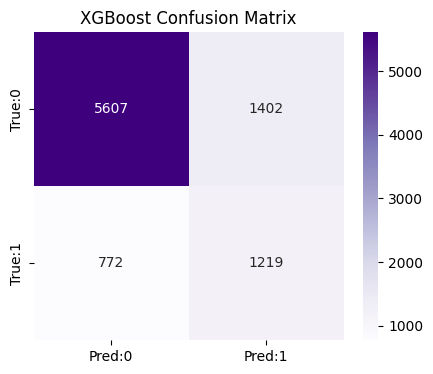


XGBoost 特徵重要度 Top 10:
1. PAY_0: 0.4292
2. PAY_4: 0.0663
3. PAY_2: 0.0463
4. PAY_3: 0.0432
5. PAY_6: 0.0332
6. PAY_AMT2: 0.0287
7. PAY_5: 0.0258
8. UTILIZATION: 0.0242
9. PAY_AMT1: 0.0230
10. PAY_AMT3: 0.0212


In [8]:
# Part 5: 進階加分題 - 特徵工程與 XGBoost
# (Feature Engineering & Cost-Sensitive XGBoost)

import xgboost as xgb
from xgboost import XGBClassifier

print("\n🚀 正在進行特徵工程 (Feature Engineering)...")

# 1. 創造金融特徵 (Financial Features)
# 為了不影響原始 df，我們先 copy 一份
df_eng = df.copy()

# [特徵 A] 額度使用率 (Credit Utilization)
# 邏輯：欠款越多，接近額度上限，風險越高
# 為了避免除以 0，分母加一個小數
df_eng['UTILIZATION'] = df_eng['BILL_AMT1'] / (df_eng['LIMIT_BAL'] + 1)

# [特徵 B] 帳單增長率 (Bill Growth)
# 邏輯：這個月帳單(BILL_AMT1)比上個月(BILL_AMT2)暴增嗎？
df_eng['BILL_GROWTH'] = (df_eng['BILL_AMT1'] - df_eng['BILL_AMT2']) / (df_eng['BILL_AMT2'].abs() + 1)

# [特徵 C] 近期還款能力 (Payment Coverage)
# 邏輯：上個月的帳單(BILL_AMT2)，你這個月還(PAY_AMT1)了多少？
# 如果 PAY_AMT1 / BILL_AMT2 < 1 代表沒還完 (Revolving)
df_eng['PAY_RATIO'] = df_eng['PAY_AMT1'] / (df_eng['BILL_AMT2'].abs() + 1)

print("新特徵已建立：UTILIZATION, BILL_GROWTH, PAY_RATIO")

# 2. 重新切分資料 (因為特徵變了)
X_eng = df_eng.drop(columns=[target]) # 記得 target 還是同一個
y_eng = df_eng[target]

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.3, random_state=42, stratify=y_eng
)

# 3. 建立 XGBoost 模型 (包含成本敏感設定)
# scale_pos_weight:用來處理不平衡。
# 公式通常是：(負樣本數 / 正樣本數)。這裡大約是 78/22 ≈ 3.5
# 這告訴模型：「抓到一個違約者(1)的重要性，是抓到正常人(0)的 3.5 倍」
ratio = float(np.sum(y_train_eng == 0)) / np.sum(y_train_eng == 1)

print(f"\n正在訓練 XGBoost (scale_pos_weight={ratio:.2f})...")

xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=ratio, # [重點] 成本敏感學習
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train_eng, y_train_eng)
y_pred_xgb = xgb_clf.predict(X_test_eng)

# 4. 評估與比較
print("\n===== XGBoost (with Feature Engineering) 評估結果 =====")
print(classification_report(y_test_eng, y_pred_xgb, target_names=['No Default(0)', 'Default(1)']))

# 顯示混淆矩陣
plt.figure(figsize=(5, 4))
cm_xgb = confusion_matrix(y_test_eng, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Pred:0', 'Pred:1'],
            yticklabels=['True:0', 'True:1'])
plt.title('XGBoost Confusion Matrix')
plt.show()

# 5. 查看新特徵有沒有用？
xgb_importances = xgb_clf.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]
print("\nXGBoost 特徵重要度 Top 10:")
for f in range(10):
    print(f"{f + 1}. {X_eng.columns[xgb_indices[f]]}: {xgb_importances[xgb_indices[f]]:.4f}")